# Credit Risk Analytics & GenAI Assistant

## Exploratory Data Analysis (EDA)

### Objetivo

Analizar el comportamiento de los clientes y sus características financieras para identificar patrones relacionados con incumplimiento crediticio.

Este análisis servirá como base para:

- Selección de variables
- Ingeniería de características
- Modelamiento predictivo
- Recomendaciones de negocio

In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

from src.data import load_data

In [23]:
df = load_data("german_credit.csv")

df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0


In [24]:
print("Dimensiones:")
print(df.shape)

print("\nInformación:")
df.info()

Dimensiones:
(1000, 21)

Información:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   status                   1000 non-null   str  
 1   duration                 1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   amount                   1000 non-null   int64
 5   savings                  1000 non-null   str  
 6   employment_duration      1000 non-null   str  
 7   installment_rate         1000 non-null   int64
 8   personal_status_sex      1000 non-null   str  
 9   other_debtors            1000 non-null   str  
 10  present_residence        1000 non-null   int64
 11  property                 1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000 

In [25]:
df.describe()

,duration,amount,installment_rate,present_residence,age,number_credits,people_liable,credit_risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,0.700000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,1.000000


In [21]:
df.columns

Index(['status', 'loan_duration_months', 'credit_history_status', 'purpose',
       'loan_amount', 'savings', 'employment_duration', 'installment_ratio',
       'personal_status_sex', 'other_debtors', 'present_residence', 'property',
       'customer_age', 'other_installment_plans', 'housing', 'number_credits',
       'job', 'people_liable', 'telephone', 'foreign_worker', 'credit_risk'],
      dtype='str')

In [26]:
df.isnull().sum().sort_values(
    ascending=False
)

status                     0
duration                   0
credit_history             0
purpose                    0
amount                     0
savings                    0
employment_duration        0
installment_rate           0
personal_status_sex        0
other_debtors              0
present_residence          0
property                   0
age                        0
other_installment_plans    0
housing                    0
number_credits             0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64

In [27]:
df.nunique().sort_values()

credit_risk                  2
foreign_worker               2
telephone                    2
people_liable                2
other_installment_plans      3
housing                      3
other_debtors                3
status                       4
number_credits               4
installment_rate             4
present_residence            4
job                          4
personal_status_sex          4
property                     4
credit_history               5
savings                      5
employment_duration          5
purpose                     10
duration                    33
age                         53
amount                     921
dtype: int64

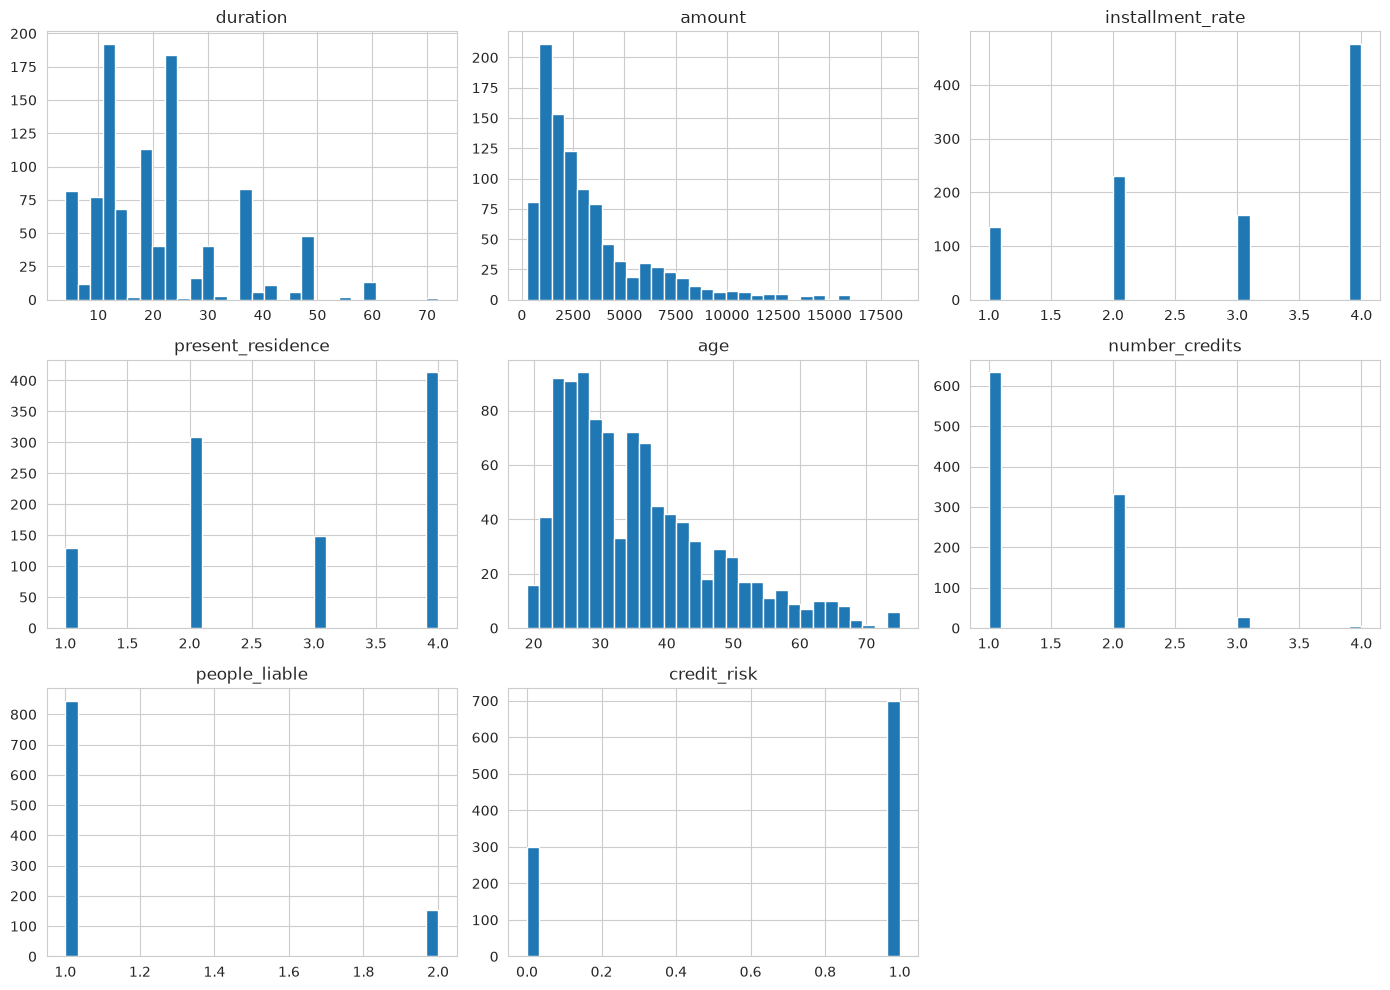

In [28]:
df.hist(
    figsize=(14,10),
    bins=30
)

plt.tight_layout()
plt.show()

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="default"
)

plt.title(
    "Distribución de Default"
)

plt.show()

ValueError: Could not interpret value `default` for `x`. An entry with this name does not appear in `data`.

<Figure size 600x400 with 0 Axes>

In [30]:
default_rate = df["default"].mean()

print(
    f"Tasa de default: {default_rate:.2%}"
)

KeyError: 'default'

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="default",
    y="amount"
)

plt.title(
    "Monto del crédito vs Default"
)

plt.show()

ValueError: Could not interpret value `default` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x500 with 0 Axes>

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="default",
    y="age"
)

plt.title(
    "Edad vs Default"
)

plt.show()

ValueError: Could not interpret value `default` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x500 with 0 Axes>

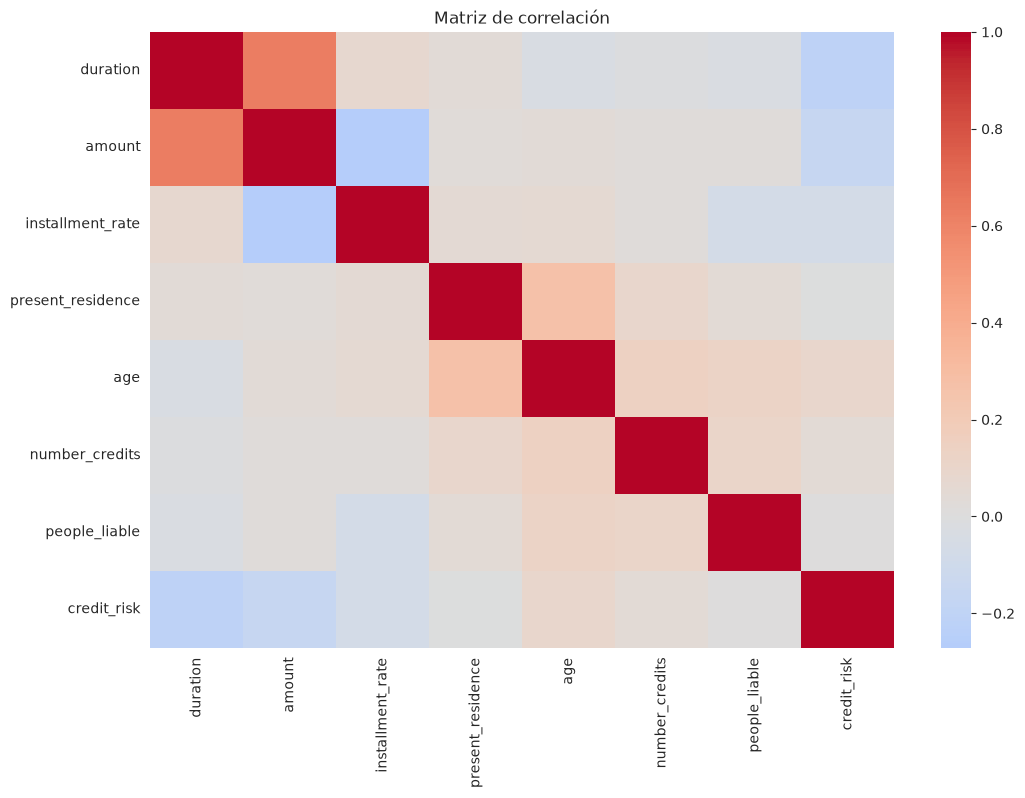

In [33]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    center=0
)

plt.title(
    "Matriz de correlación"
)

plt.show()

# Conclusiones del análisis

## Calidad de datos

Pendiente completar después del análisis.

## Hallazgos de negocio

Pendiente completar después del análisis.

## Próximos pasos

- Ingeniería de variables.
- Codificación de variables categóricas.
- Construcción del pipeline de Machine Learning.